In [1]:
# ============================================
# SECCIÓN 6. CLUSTERING JERÁRQUICO
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# --------------------------------------------
# 1. Carga del dataset
# --------------------------------------------
df = sns.load_dataset("penguins").copy()

In [3]:
# --------------------------------------------
# 1. Selección de variables numéricas
# --------------------------------------------
vars_numericas = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

df_hc = df[vars_numericas + ["species", "sex"]].dropna(subset=vars_numericas).copy()

In [4]:
# --------------------------------------------
# 2. Estandarización de variables
# --------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_hc[vars_numericas])

In [5]:
# --------------------------------------------
# 3. Clustering jerárquico
# Método de Ward + distancia euclídea
# --------------------------------------------
Z = linkage(X_scaled, method="ward")


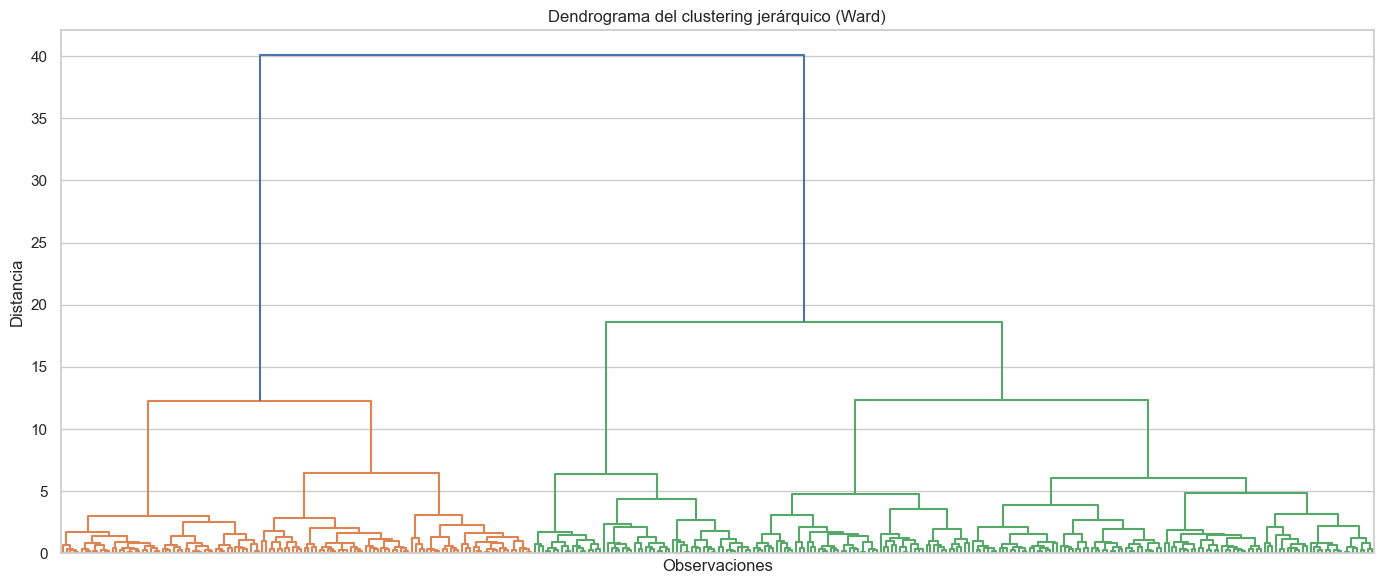

In [6]:
# --------------------------------------------
# 4. Dendrograma
# --------------------------------------------
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode=None,
    no_labels=True,
    color_threshold=None
)

plt.title("Dendrograma del clustering jerárquico (Ward)")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


In [7]:
# --------------------------------------------
# 5. Sugerencia de número de grupos
# Puedes ajustar n_clusters según el dendrograma
# --------------------------------------------
n_clusters = 3

clusters_hc = fcluster(Z, t=n_clusters, criterion="maxclust")
df_hc["cluster_hierarquico"] = clusters_hc

In [8]:
# --------------------------------------------
# 6. Tamaño de los grupos
# --------------------------------------------
print("Frecuencia por cluster jerárquico:")
display(df_hc["cluster_hierarquico"].value_counts().sort_index())

Frecuencia por cluster jerárquico:


cluster_hierarquico
1    123
2     57
3    162
Name: count, dtype: int64

In [9]:
# --------------------------------------------
# 7. Tabla cruzada con species
# --------------------------------------------
print("Tabla cruzada: cluster jerárquico vs species")
tabla_clusters_species = pd.crosstab(
    df_hc["cluster_hierarquico"],
    df_hc["species"],
    margins=True
)
display(tabla_clusters_species)

Tabla cruzada: cluster jerárquico vs species


species,Adelie,Chinstrap,Gentoo,All
cluster_hierarquico,,,,
1,0,0,123,123
2,0,57,0,57
3,151,11,0,162
All,151,68,123,342


In [10]:
# --------------------------------------------
# 8. Perfil medio de cada cluster
# --------------------------------------------
print("Medias de variables numéricas por cluster jerárquico:")
perfil_clusters = (
    df_hc.groupby("cluster_hierarquico")[vars_numericas]
    .mean()
    .round(2)
)
display(perfil_clusters)

Medias de variables numéricas por cluster jerárquico:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster_hierarquico,,,,
1,47.50,14.98,217.19,"5,076.02"
2,49.75,18.60,197.11,"3,810.09"
3,39.15,18.29,189.90,"3,675.77"


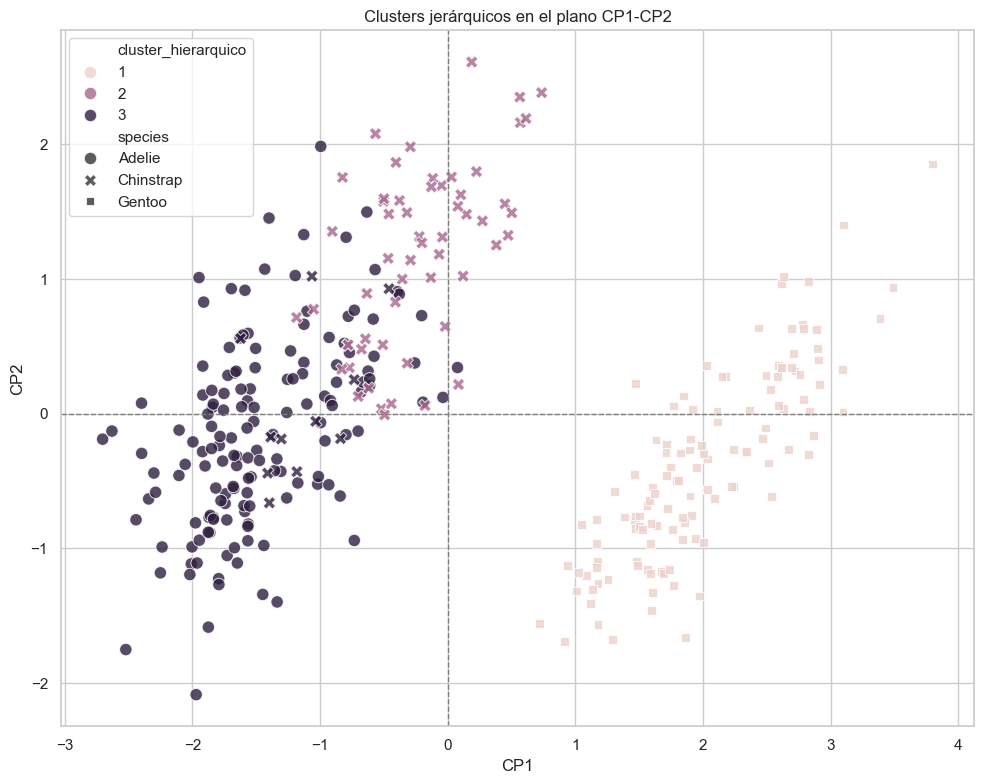

In [11]:
# --------------------------------------------
# 9. Visualización en el plano PCA (si ya tienes df_scores)
# Si no lo tienes, esta parte genera PCA solo para visualizar
# --------------------------------------------
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

df_hc["CP1"] = X_pca_vis[:, 0]
df_hc["CP2"] = X_pca_vis[:, 1]

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_hc,
    x="CP1",
    y="CP2",
    hue="cluster_hierarquico",
    style="species",
    s=80,
    alpha=0.8
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.title("Clusters jerárquicos en el plano CP1-CP2")
plt.xlabel("CP1")
plt.ylabel("CP2")
plt.tight_layout()
plt.show()